
Hasil Evaluasi Fuzzy C-Means (Library)

Waktu Eksekusi   : 0.2050 detik
Silhouette Score : 0.6674



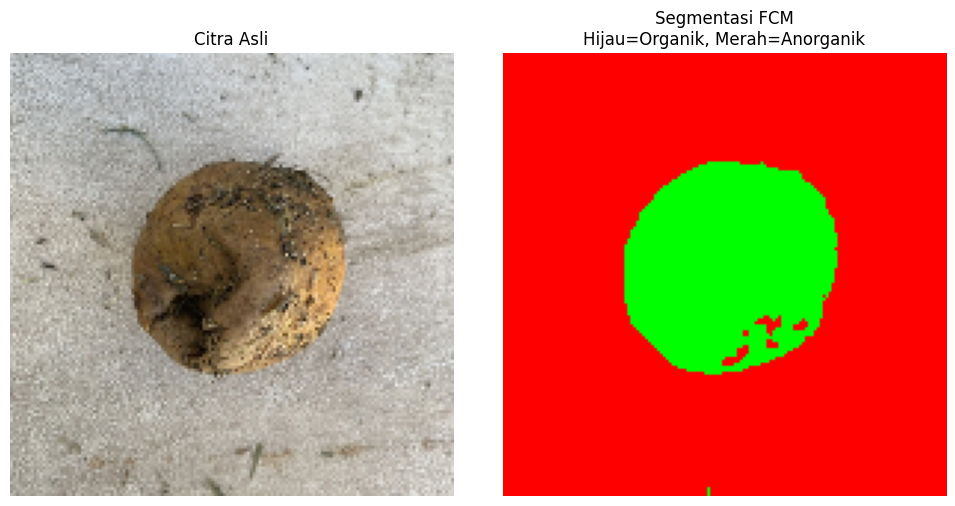

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import skfuzzy as fuzz
from sklearn.metrics import silhouette_score

def interpretasi_sampah(centroids):
    skor = [
        (10 if 0.05 <= h <= 0.48 else 0) +
        (2 if 0.2 <= s <= 0.7 else 0)
        for h, s, _ in centroids
    ]

    if skor[0] != skor[1]:
        idx_organik = int(np.argmax(skor))
    else:
        idx_organik = int(np.argmin(centroids[:, 1]))

    return idx_organik, 1 - idx_organik

def jalankan_eksperimen_fcm(path_gambar):
    img_bgr = cv2.imread(path_gambar)

    if img_bgr is None:
        return

    img_resized = cv2.resize(img_bgr, (150, 150))

    img_hsv = cv2.cvtColor(
        cv2.GaussianBlur(img_resized, (5, 5), 0),
        cv2.COLOR_BGR2HSV
    )

    h, w, _ = img_hsv.shape

    piksel = img_hsv.reshape(-1, 3).astype(np.float32)
    piksel /= np.array([179.0, 255.0, 255.0])

    warna = {
        'organik': [0, 255, 0],
        'anorganik': [0, 0, 255]
    }

    print("\nHasil Evaluasi Fuzzy C-Means (Library)\n")

    mulai = time.perf_counter()

    data_fcm = piksel.T

    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data_fcm,
        c=2,
        m=2.0,
        error=1e-4,
        maxiter=30,
        init=None,
        seed=42
    )

    waktu = time.perf_counter() - mulai

    labels = np.argmax(u, axis=0)

    silhouette = silhouette_score(
        piksel,
        labels,
        sample_size=2000,
        random_state=42
    )

    print(f"Waktu Eksekusi   : {waktu:.4f} detik")
    print(f"Silhouette Score : {silhouette:.4f}\n")

    idx_org, idx_anorg = interpretasi_sampah(cntr)

    seg = np.zeros((len(labels), 3), dtype=np.uint8)

    seg[labels == idx_org] = warna['organik']
    seg[labels == idx_anorg] = warna['anorganik']

    hasil_seg = seg.reshape(h, w, 3)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Citra Asli")
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(hasil_seg, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Segmentasi FCM\nHijau=Organik, Merah=Anorganik")
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('hasil_segmentasi_fcm_instan.png')
    plt.show()

jalankan_eksperimen_fcm('Food Organics_2.jpg')